In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq
import seaborn as sns

from torch.nn import functional as F

from netam import pretrained
from netam.models import DEFAULT_NEUTRAL_MODEL

from dnsmex.dxsm_data import pcp_df_of_nickname, anarci_dict
from dnsmex.local import localify
from netam.oe_plot import annotate_sites_df, annotate_site_csp_df, get_numbering_dict

figures_dir = localify("FIGURES_DIR")
neutral_model_name = DEFAULT_NEUTRAL_MODEL

In [2]:
dataset = "v1rodriguez_short"


class MutabilityContainer:
    def __init__(self, neutral_model_name, dataset="v1rodriguez_short"):
        pcp_df = pcp_df_of_nickname(dataset, add_shm_outputs=True)
        self.pcp_df = pcp_df
        crepe = pretrained.load(neutral_model_name)
        
        self.rates, self.csp_logits = crepe(self.pcp_df["parent_heavy"])

        self.csp_rates = F.softmax(self.csp_logits, dim=2)


        anarci_path = anarci_dict[dataset]
        print(f"Using ANARCI path: {anarci_path}")
        if "imgt" in anarci_path:
            self.numbering_type = "IMGT"
        
        pcp_df_heavy = pcp_df

        for colname in pcp_df.columns:
            shortened_colname = colname[: -len("_heavy")]
            if colname.endswith("_heavy"):
                pcp_df_heavy[shortened_colname] = pcp_df_heavy[colname]

        self.pcp_df = pcp_df_heavy

        self.numbering, _ = get_numbering_dict(
            anarci_path['heavy'], self.pcp_df, verbose=True, checks="imgt"
        )

        self.create_nucleotide_neutral_rates_df()
    
    def create_nucleotide_neutral_rates_df(self):
        """
        Create a dataframe with one row per sequence, site, and nucleotide.
        No aggregations - just raw rates and csp_logits.
        Includes codon information and transition details.
        
        Returns:
        - DataFrame with columns: sequence_idx, site, nucleotide, rate, csp_logit,
                                 current_codon, codon_position, current_nucleotide, 
                                 transition_from, transition_to
        """
        n_sequences = self.rates.shape[0]
        n_sites = self.rates.shape[1] 
        nucleotides = ['A', 'C', 'G', 'T']
        
        rows = []
        
        for seq_idx in range(n_sequences):
            parent_seq = self.pcp_df.iloc[seq_idx]['parent']
            seq_length = len(parent_seq)  # Get actual sequence length
            
            for site_idx in range(n_sites):
                rate = self.rates[seq_idx, site_idx].item()
                
                # Only process sites that exist in the sequence
                if site_idx < seq_length:
                    # Get codon information for this site
                    codon_start = (site_idx // 3) * 3
                    codon_position = site_idx % 3  # 0, 1, or 2 within the codon
                    
                    # Make sure we don't go beyond sequence length for codon
                    if codon_start + 2 < seq_length:
                        current_codon = parent_seq[codon_start:codon_start + 3]
                    else:
                        current_codon = None  # Incomplete codon at end
                    
                    current_nucleotide = parent_seq[site_idx]
                else:
                    # Sites beyond sequence length - model padding
                    current_codon = None
                    codon_position = None
                    current_nucleotide = None
                
                for nuc_idx, nucleotide in enumerate(nucleotides):
                    csp_rate = self.csp_rates[seq_idx, site_idx, nuc_idx].item()
                    
                    # Determine the transition being tested
                    if current_nucleotide is not None and current_codon is not None:
                        transition_from = current_nucleotide
                        transition_to = nucleotide
                        
                        # Calculate the resulting codon after transition
                        codon_list = list(current_codon)
                        codon_list[codon_position] = nucleotide
                        transition_codon = ''.join(codon_list)
                    else:
                        transition_from = None
                        transition_to = nucleotide
                        transition_codon = None
                    
                    rows.append({
                        'pcp_index': seq_idx,
                        'site': site_idx,
                        'nucleotide': nucleotide,
                        'rate': rate,
                        'csp': csp_rate,
                        'current_codon': current_codon,
                        'codon_position': codon_position,
                        'current_nucleotide': current_nucleotide,
                        'transition_codon': transition_codon
                    })
        
        nuc_neutral_df = pd.DataFrame(rows)
        nuc_neutral_df = nuc_neutral_df[~nuc_neutral_df.current_codon.isna()]


        # amino acid site annotation
        temp_annotation_df = nuc_neutral_df[['pcp_index', 'site']].drop_duplicates().copy()
        temp_annotation_df['unannotated_nuc_site'] = temp_annotation_df['site'].copy()
        temp_annotation_df['aa_site'] = temp_annotation_df.site // 3
        annotated_temp_annotation_df = annotate_sites_df(temp_annotation_df[['pcp_index', 'aa_site']].drop_duplicates(), self.pcp_df, numbering_dict=self.numbering, add_codons_aas=True)
        temp_annotation_df = pd.merge(annotated_temp_annotation_df, temp_annotation_df[['pcp_index', 'aa_site', 'unannotated_nuc_site']], on=['pcp_index', 'aa_site'], how='inner')
        temp_annotation_df.drop(columns=['aa_site'], inplace=True)
        temp_annotation_df = temp_annotation_df[['pcp_index', 'site', 'unannotated_nuc_site', 'is_cdr', 'parent_codon', 'parent_aa','child_codon', 'child_aa',]].rename(columns={'unannotated_nuc_site':'nuc_site'})
        nuc_neutral_df = pd.merge(nuc_neutral_df.rename(columns={'site':'nuc_site'}), temp_annotation_df, on=['pcp_index', 'nuc_site'], how='inner')

        # change rate to praobiblity for constant branch length
        branch_length = 0.1
        nuc_neutral_df['probability'] = nuc_neutral_df['rate'].apply(lambda x: 1.0 - np.exp(-branch_length * x))

        # get complete rate of mutation to specific nucleotide
        nuc_neutral_df['csp_complete_probability'] = nuc_neutral_df['probability'] * nuc_neutral_df['csp']

        # add amino acids transition information
        nuc_neutral_df['current_aa']  = nuc_neutral_df.apply(lambda row: Seq(row['current_codon']).translate() if row['transition_codon'] is not None else None, axis=1)
        nuc_neutral_df['transition_aa'] = nuc_neutral_df.apply(lambda row: Seq(row['transition_codon']).translate() if row['transition_codon'] is not None else None, axis=1)

        self.nuc_neutral_df = nuc_neutral_df



MutabilityContainer = MutabilityContainer(neutral_model_name)


/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:476: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(


Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200


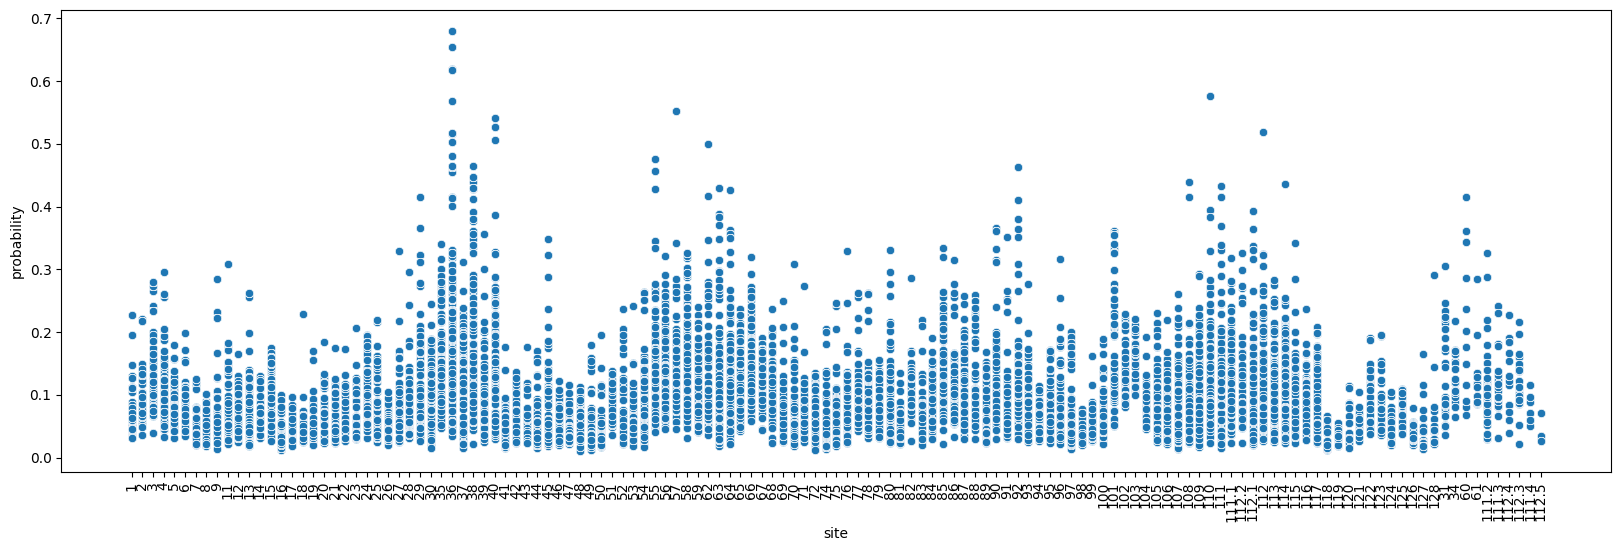

In [36]:
fix, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=MutabilityContainer.nuc_neutral_df, x='site', y='probability',ax=ax)
ax.tick_params(axis='x', rotation=90)


In [30]:
MutabilityContainer.pcp_df

,orig_pcp_idx,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,...,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,j_gene,v_family,nt_rates,nt_csps
0,16,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,1TGCGTTGTAGCT,CAGATCCAACTGGTCCAATCTGGGTCTGACTTGAAAAAGCCTGGGG...,0.082506,2,0.096444,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
1,17,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,Node2,CAGGTGCAGTTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,0.018034,2,0.031971,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
2,32,sample-igg-SC-24,474,Node1,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,Node2,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,0.002823,2,0.079722,...,75,96,150,168,285,318,IGHJ4*02,IGHV4,"[tensor(0.5329), tensor(0.6757), tensor(2.1780...","[[tensor(0.2261), tensor(0.), tensor(0.2757), ..."
3,45,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GGGCACTATGCA,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.029887,2,0.094379,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
4,46,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GCAGGGCACTCT,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.005211,2,0.069703,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,506,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TTCTTCTGGGAC,CAGGTGCAGTTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,0.096086,3,0.123178,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
95,507,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TGTATAAGTTGG,CAGGTGCACCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGAA...,0.107150,3,0.134241,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
96,531,sample-igg-SC-24,72,Node1,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,1TGTGGATTTAAC,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,0.002876,2,0.097942,...,75,96,150,171,288,312,IGHJ1*01,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.8237...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
97,541,sample-igg-SC-24,383,Node1,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,1TCTTTGCTAGTG,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,0.005669,2,0.163680,...,75,99,153,171,288,321,IGHJ4*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."


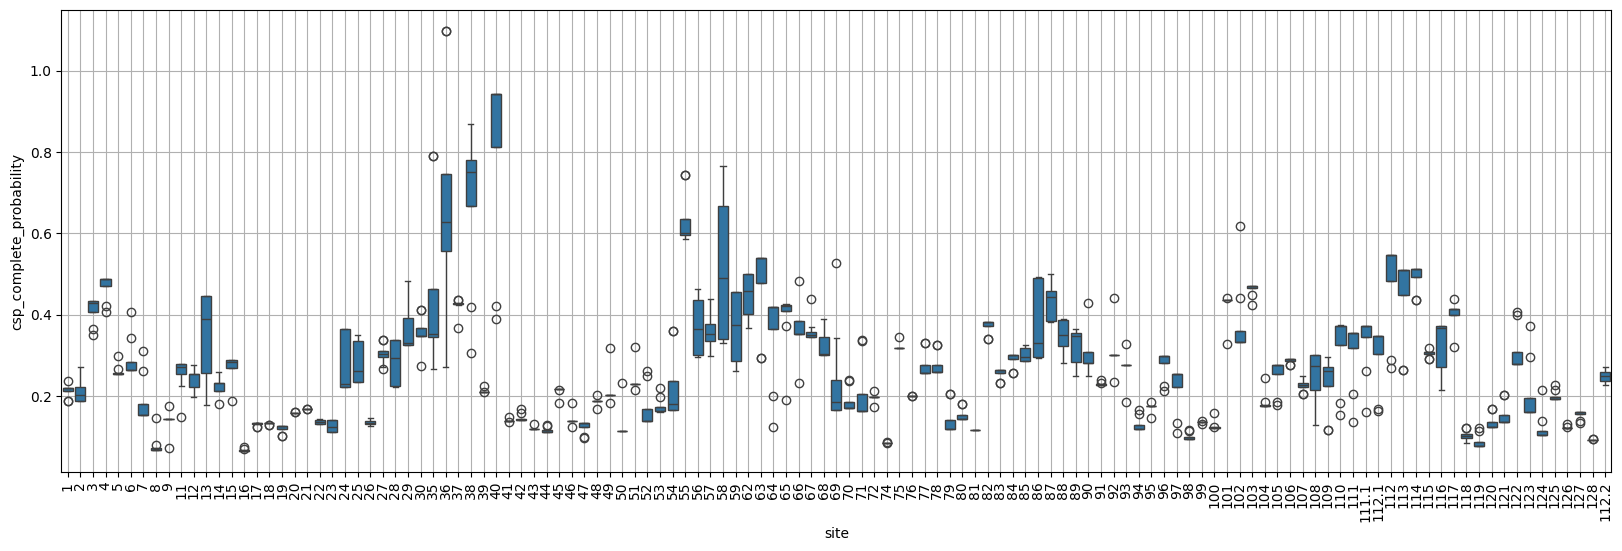

In [7]:
v3_pcps = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df['v_gene_heavy'].str.startswith('IGHV3-23*01')].index.tolist()

plot_data = MutabilityContainer.nuc_neutral_df[(MutabilityContainer.nuc_neutral_df.pcp_index.isin(v3_pcps))].groupby(['pcp_index', 'site'], sort=False).csp_complete_probability.sum().reset_index()
#plot_data['full_transition_aa'] = plot_data['current_aa'] + '>' + plot_data['transition_aa']

fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=plot_data, x='site', y='csp_complete_probability', ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.grid()


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


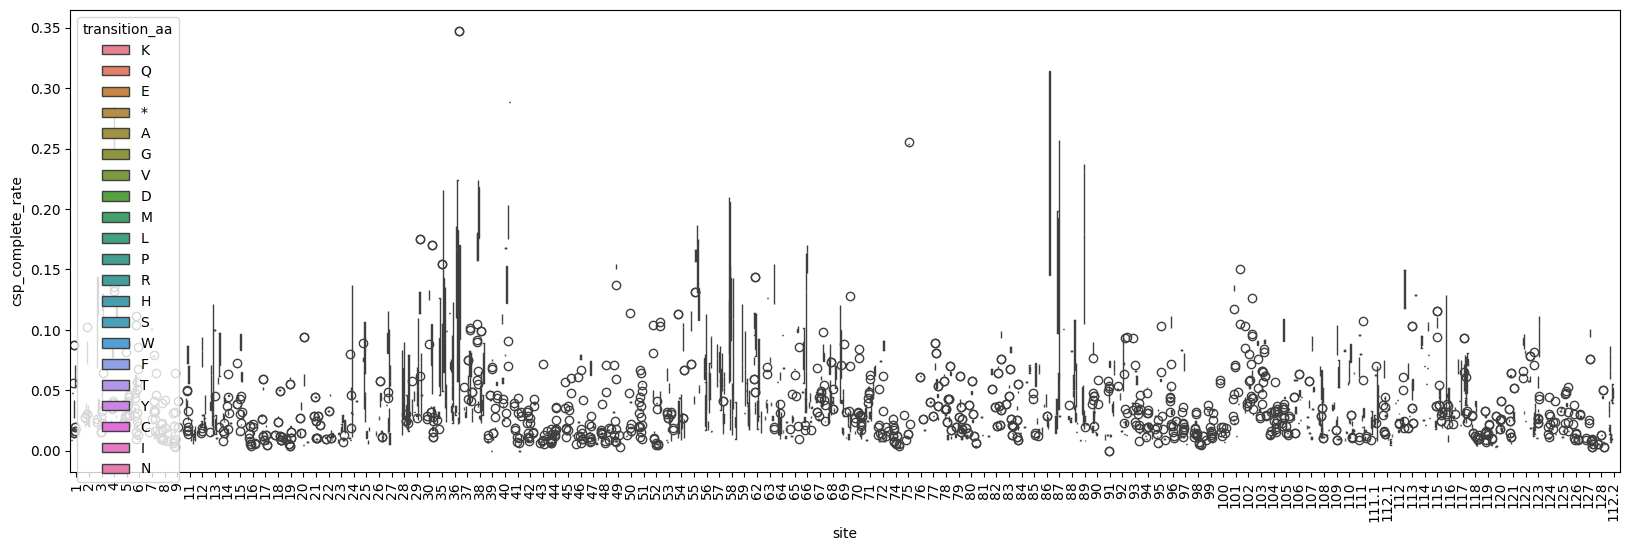

In [ ]:
v3_pcps = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df['v_gene_heavy'].str.startswith('IGHV3-23*01')].index.tolist()

plot_data = MutabilityContainer.nuc_neutral_df[(MutabilityContainer.nuc_neutral_df.pcp_index.isin(v3_pcps))].groupby(['pcp_index', 'site', 'current_aa', 'transition_aa'], sort=False).csp_complete_rate.sum().reset_index()
plot_data['full_transition_aa'] = plot_data['current_aa'] + '>' + plot_data['transition_aa']

fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=plot_data, x='site', y='csp_complete_probability', hue='transition_aa', ax=ax)
ax.tick_params(axis='x', rotation=90)


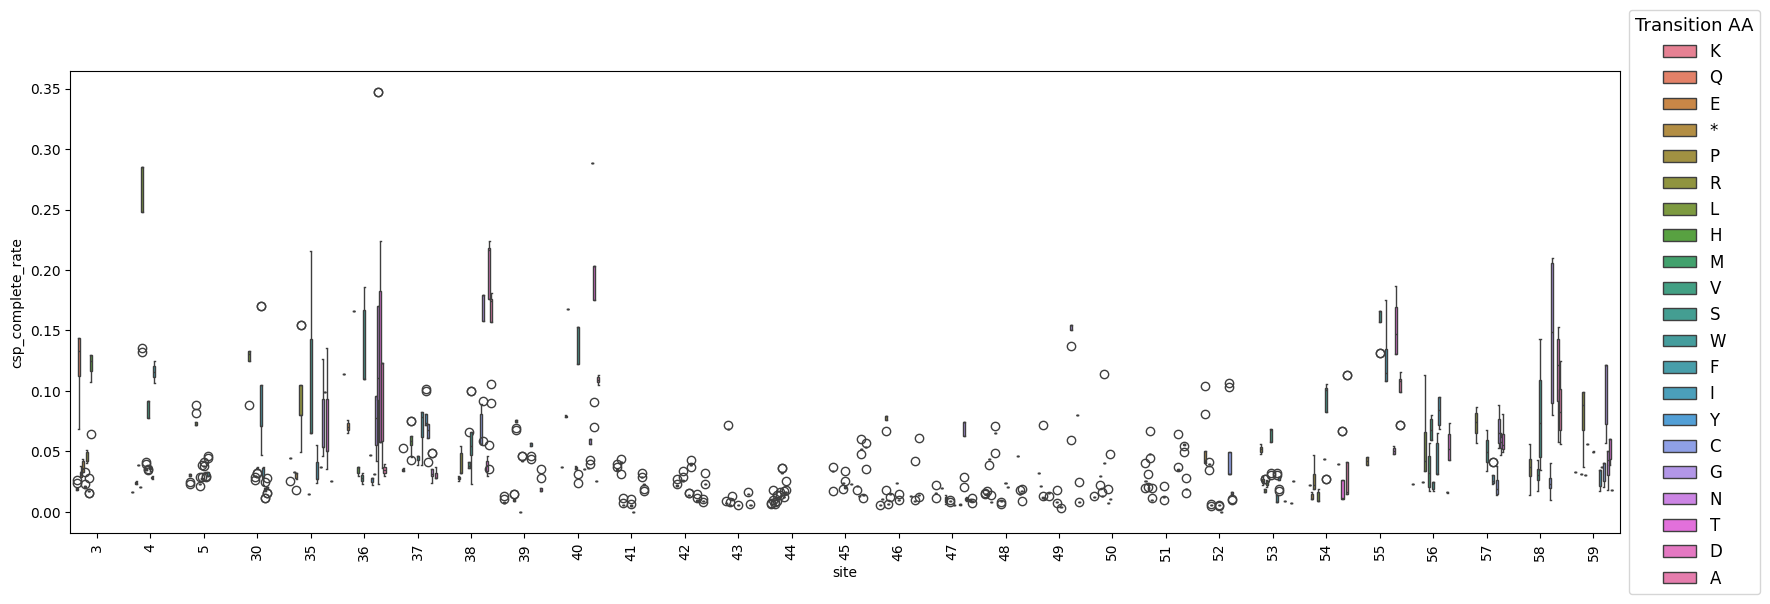

In [49]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=plot_data[(plot_data.site.str.startswith('3')) | (plot_data.site.str.startswith('4')) + (plot_data.site.str.startswith('5'))], x='site', y='csp_complete_rate', hue='transition_aa', ax=ax)
ax.tick_params(axis='x', rotation=90)
# move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Transition AA', fontsize=12, title_fontsize='13')


In [ ]:
MutabilityContainer.nuc_neutral_df[(MutabilityContainer.nuc_neutral_df.pcp_index.isin(v3_pcps))]

,pcp_index,nuc_site,nucleotide,rate,csp,current_codon,codon_position,current_nucleotide,transition_codon,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,probability,csp_complete_rate,current_aa,transition_aa
56832,39,0,A,0.465943,0.192243,GAG,0.0,G,AAG,1,False,GAG,E,GAG,E,0.045525,0.008752,(E),(K)
56833,39,0,C,0.465943,0.467961,GAG,0.0,G,CAG,1,False,GAG,E,GAG,E,0.045525,0.021304,(E),(Q)
56834,39,0,G,0.465943,0.000000,GAG,0.0,G,GAG,1,False,GAG,E,GAG,E,0.045525,0.000000,(E),(E)
56835,39,0,T,0.465943,0.339797,GAG,0.0,G,TAG,1,False,GAG,E,GAG,E,0.045525,0.015469,(E),(*)
56836,39,1,A,0.648034,0.000000,GAG,1.0,A,GAG,1,False,GAG,E,GAG,E,0.062748,0.000000,(E),(E)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128407,87,367,T,0.211075,0.360640,TCT,1.0,C,TTT,128,False,TCT,S,TCT,S,0.020886,0.007532,(S),(F)
128408,87,368,A,0.519453,0.181977,TCT,2.0,T,TCA,128,False,TCT,S,TCT,S,0.050619,0.009212,(S),(S)
128409,87,368,C,0.519453,0.530155,TCT,2.0,T,TCC,128,False,TCT,S,TCT,S,0.050619,0.026836,(S),(S)
128410,87,368,G,0.519453,0.287868,TCT,2.0,T,TCG,128,False,TCT,S,TCT,S,0.050619,0.014572,(S),(S)


In [ ]:
## the neutral substitution rates at the sites of interest are very high, meanwhile the selection factors are very low.
## do we need to make sure that the counts in the non productive data for thrifty is truly high? Thrifty works on k-mers, make sure that for these specific sites they match the prediction of their k-mer.

In [42]:
plot_data[plot_data.site == '38'].groupby('full_transition_aa').csp_complete_rate.median().sort_values(ascending=False)

full_transition_aa
(G, >, D)    0.216712
(G, >, G)    0.179684
(G, >, A)    0.174671
(A, >, A)    0.097698
(A, >, G)    0.075464
(G, >, C)    0.056074
(G, >, S)    0.054514
(A, >, V)    0.052940
(A, >, D)    0.045356
(A, >, T)    0.037797
(G, >, V)    0.035862
(G, >, R)    0.032256
(A, >, P)    0.027762
(A, >, S)    0.024169
Name: csp_complete_rate, dtype: float64

In [43]:
plot_data[plot_data.site == '55'].groupby('full_transition_aa').csp_complete_rate.median().sort_values(ascending=False)

full_transition_aa
(T, >, S)    0.166138
(T, >, T)    0.147182
(T, >, I)    0.114706
(T, >, A)    0.107931
(T, >, N)    0.050155
(T, >, P)    0.042152
Name: csp_complete_rate, dtype: float64

In [47]:
plot_data[plot_data.site == '35'].groupby('full_transition_aa').csp_complete_rate.median().sort_values(ascending=False)

full_transition_aa
(S, >, S)    0.215930
(S, >, R)    0.154380
(S, >, T)    0.135739
(G, >, G)    0.126201
(S, >, N)    0.099173
(S, >, G)    0.093599
(R, >, R)    0.080278
(R, >, S)    0.065108
(S, >, I)    0.055139
(R, >, G)    0.053249
(R, >, T)    0.050365
(G, >, R)    0.049341
(R, >, K)    0.044891
(S, >, C)    0.037330
(G, >, E)    0.032724
(R, >, *)    0.032435
(R, >, I)    0.026953
(G, >, A)    0.025753
(G, >, *)    0.017669
(G, >, V)    0.015051
Name: csp_complete_rate, dtype: float64

In [44]:
plot_data[plot_data.site == '57'].groupby('full_transition_aa').csp_complete_rate.median().sort_values(ascending=False)

full_transition_aa
(S, >, R)    0.073981
(S, >, G)    0.065288
(S, >, N)    0.058088
(S, >, T)    0.055661
(S, >, S)    0.049899
(S, >, I)    0.025467
(S, >, C)    0.018797
Name: csp_complete_rate, dtype: float64

In [7]:
MutabilityContainer.csp_logits.shape

torch.Size([1000, 500, 4])

In [15]:
MutabilityContainer.subset_df.shape

(1000, 36)

In [34]:
MutabilityContainer.pcp_df

,orig_pcp_idx,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,...,cdr2_codon_start_light,cdr2_codon_end_light,cdr3_codon_start_light,cdr3_codon_end_light,j_gene_light,v_family_light,nt_rates_heavy,nt_csps_heavy,nt_csps_light,nt_rates_light
0,16,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,1TGCGTTGTAGCT,CAGATCCAACTGGTCCAATCTGGGTCTGACTTGAAAAAGCCTGGGG...,0.082506,2,0.096444,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...",[],[]
1,17,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,Node2,CAGGTGCAGTTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,0.018034,2,0.031971,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...",[],[]
2,32,sample-igg-SC-24,474,Node1,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,Node2,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,0.002823,2,0.079722,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.5329), tensor(0.6757), tensor(2.1780...","[[tensor(0.2261), tensor(0.), tensor(0.2757), ...",[],[]
3,45,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GGGCACTATGCA,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.029887,2,0.094379,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...",[],[]
4,46,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GCAGGGCACTCT,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.005211,2,0.069703,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...",[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21747,311243,sample-igg-W-109,62,Node1,CAGGTGCAGTTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGG...,1TCGGCAATGTAT,CAGGTGCAGTTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGG...,0.002731,2,0.039758,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...",[],[]
21748,311261,sample-igg-W-109,10,Node1,GAGGCTCAACTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCGGGGG...,Node2,GAGGCTCAACTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCGGGGG...,0.002848,2,0.109737,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.6559), tensor(0.7319), tensor(0.4964...","[[tensor(0.1651), tensor(0.4102), tensor(0.), ...",[],[]
21749,311271,sample-igg-W-109,10,Node2,GAGGCTCAACTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCGGGGG...,1TTTGTTCCTATG,GAGGCTCAACTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCGGGGG...,0.002848,3,0.112585,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.6559), tensor(0.7319), tensor(0.4964...","[[tensor(0.1651), tensor(0.4102), tensor(0.), ...",[],[]
21750,311275,sample-igg-W-117,10,Node1,CAAATTCAGCTGGTCCAGTCTGTCTCTGAGGTGAAGAAGCCTGGGG...,1AAAGGGCCAGTT,CAAATTCAGCTGGTCCAGTCTGTCTCTGAGGTGAAGAAGCCTGTGG...,0.002803,2,0.119753,...,<NA>,<NA>,<NA>,<NA>,,,"[tensor(0.4615), tensor(0.7251), tensor(1.2222...","[[tensor(0.2204), tensor(0.), tensor(0.3042), ...",[],[]


In [ ]:
g